In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [13]:
## 读取图片与灰度转换
def BGR_to_gray(image):
    # 读取图片
    img = cv.imread("./light.png")

    # 检查图片是否成功读取
    if img is None:
        print("Error: Unable to load image. Please check the file path.")
    else:
        # 转换为灰度图像
        gray_image = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        # 使用matplotlib显示图像
        plt.figure(figsize=(10, 5))  # 创建一个足够大的画布
        # 显示原始图像
        plt.subplot(1, 2, 1)  # 1行2列的第1个位置
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))  # OpenCV读取的图像是BGR格式，需要转换为RGB
        plt.title("Original Image")
        plt.axis("off")  # 关闭坐标轴

        # 显示灰度图像
        plt.subplot(1, 2, 2)  # 1行2列的第2个位置
        plt.imshow(gray_image, cmap='gray')  # 灰度图像需要指定颜色映射
        plt.title("Gray Image")
        plt.axis("off")  # 关闭坐标轴

        # 显示整个画布
        plt.show()
        return gray_image

In [2]:
## 读取摄像头与视频显示
def read_camera():
    # 打开摄像头
    cap = cv.VideoCapture(0)

    if not cap.isOpened():  #
        print("无法打开摄像头")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            print("无法读取摄像头帧")
            break

        # 摄像头显示
        cv.imshow("Camera", frame)
        # 按q停止
        if cv.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv.destroyAllWindows()

In [7]:
def normalize_and_display(img):
    img = cv.imread(img)
    # 归一化为0~1
    normalized_image = cv.normalize(img, None, 0, 1.0, cv.NORM_MINMAX, dtype=cv.CV_32F)
     # 创建一个可调整大小的窗口
    cv.namedWindow("Normalized Image", cv.WINDOW_NORMAL)
     # 获取图像的原始尺寸
    height, width = img.shape[:2]
    # 设置窗口大小
    cv.resizeWindow("Normalized Image", width//3, height//3) ##参数必须是整数
    # 显示归一化后的图像
    cv.imshow("Normalized Image", normalized_image)
    cv.waitKey(0)
    cv.destroyAllWindows()

In [8]:
## 创建空白图像
def create_blank_image(width, height, color=(255, 255, 255)):
    # 创建一个指定大小和颜色的空白图像
    blank_image = np.full((height, width, 3), color, dtype=np.uint8)
    cv.imshow("Normalized Image",blank_image)
    cv.waitKey(0)
    cv.destroyAllWindows()
    return blank_image

In [9]:
## 提取ROI与分离、合并通道
def extract_roi_and_split_merge_channels(image, roi_start_point, roi_end_point):
    # 提取 ROI
    roi = image[roi_start_point[1]:roi_end_point[1], roi_start_point[0]:roi_end_point[0]]
    cv.imshow("ROI", roi)

    # 分离通道
    b, g, r = cv.split(image)
    cv.imshow("Blue Channel", b)
    cv.imshow("Green Channel", g)
    cv.imshow("Red Channel", r)

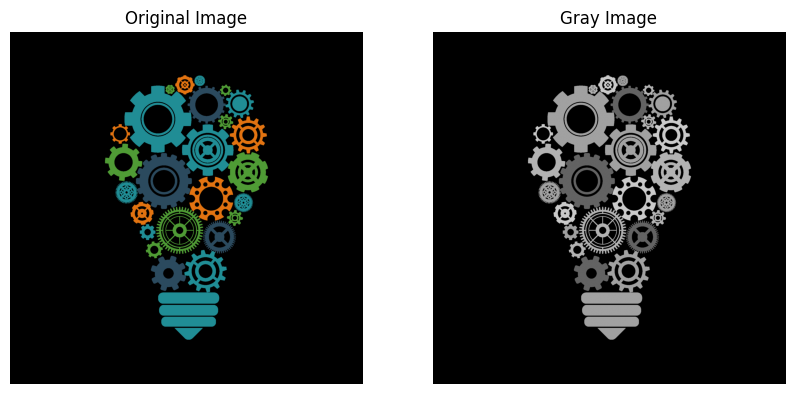

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [14]:
img = "./light.png"
BGR_to_gray(img)

In [5]:
## 读取摄像头与视频显示
read_camera()

In [16]:
## 归一化图像并显示
normalize_and_display(img)

In [17]:
create_blank_image(680, 340)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [18]:
## ROI提取
## 轮廓检测提取
import cv2
import numpy as np
img = "./light.png"
# 读取图片并且进行预处理
def processImg(path):
    '''
    path: 图片路径
    '''
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 1)
    ret, th1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU )
    # 开闭运算去除噪点
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    th1 = cv2.morphologyEx(th1, cv2.MORPH_OPEN, kernel)
    th1 = cv2.morphologyEx(th1, cv2.MORPH_CLOSE, kernel)
    edge = cv2.Canny(th1, 50, 100)

    return th1, img, edge

# 利用轮廓处理获取roi
def getRoi(img, binary):
    '''
    img: 原图
    binary: 预处理后得到的canny边缘
    '''
    # 寻找轮廓
    _, contours, _ = cv2.findContours(
        binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    roi_list = []

    # 判断出圆形区域
    for cnt in range(len(contours)):
        area = cv2.contourArea(contours[cnt])
        # 判断提取所需的轮廓，经验值需要调试获取
        if 4000 < area < 10000:
            # 获取外接矩形的值
            x,y,w,h = cv2.boundingRect(contours[cnt])
            roi_list.append((x,y,w,h))
            cv2.rectangle(img, (x,y),(x+w, y+h),(0,255,0),2)
            cv2.drawContours(img, [contours[cnt]], 0, (255, 0, 255), 2)

    return img, roi_list

# Save the roi
def saveRoi(src, roi_list):
    '''
    src: 原图的copy
    roi_list: List,保存的roi位置信息
    '''
    for i in range(len(roi_list)):
        x, y, w, h = roi_list[i]
        roi = src[y:y+h, x:x+w]
        cv2.imwrite("money_roi/roi_%d.jpg"%i, roi)
        print("No.%02d Finished! "%i)

if __name__ == '__main__':

    th1, img, edge = processImg(img)
    # copy img
    src = img.copy()
    # 获取roi
    img, roi_list = getRoi(img, edge)

    # 保存roi
    saveRoi(src, roi_list)

    # Display images.
    cv2.imshow("Thresholded Image", th1)
    cv2.imwrite("money_contour_binary.jpg", th1)

    cv2.imshow("edge", edge)
    cv2.imwrite("money_contour_edge.jpg", edge)

    cv2.imshow("roi image", img)
    cv2.imwrite("money_contour_out.jpg", img)

    cv2.waitKey(0)
    cv2.destroyAllWindows()


ValueError: not enough values to unpack (expected 3, got 2)

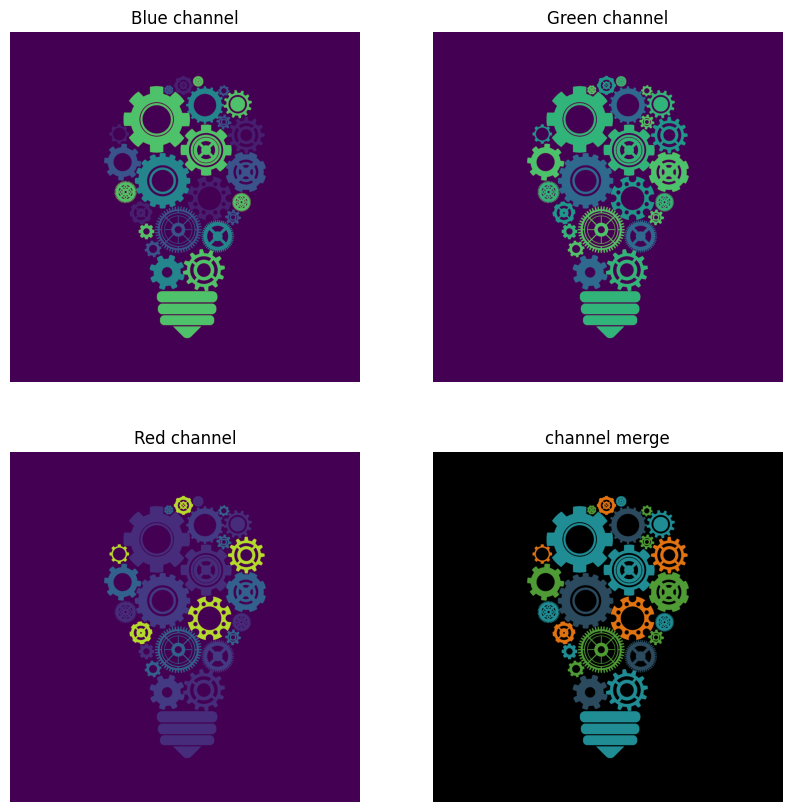

In [15]:
## 通道分离与合并
import cv2
import matplotlib.pyplot as plt
## 通道分离
img = "./light.png"
img = cv2.imread(img)
b,g,r=cv2.split(img)


# 使用matplotlib显示图像
plt.figure(figsize=(10, 10))  # 创建一个足够大的画布

# 蓝色通道
plt.subplot(2, 2, 1)
plt.imshow(b)
plt.title("Blue channel")
plt.axis("off")  # 关闭坐标轴# OpenCV读取的图像是BGR格式，需要转换为RGB


# 绿色通道
plt.subplot(2, 2, 2)
plt.imshow(g)
plt.title("Green channel")
plt.axis("off")  # 关闭坐标轴

# 红色通道
plt.subplot(2, 2, 3)
plt.imshow(r)
plt.title("Red channel")
plt.axis("off")  # 关闭坐标轴

# 合并通道
plt.subplot(2, 2, 4)
img_merge=cv2.merge([r,g,b])
plt.imshow(img_merge)
plt.title("channel merge")
plt.axis("off")  # 关闭坐标轴

# 显示整个画布
plt.show()

In [12]:
import cv2
import numpy as np

# 读取图像
image = cv2.imread('light.png')  # 替换为你的图片路径
if image is None:
    print("无法加载图像，请检查路径是否正确！")
    exit()

# 转换为灰度图
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 使用Canny算法进行边缘检测
edges = cv2.Canny(gray, 50, 150)  # 参数可以根据图像调整

# 查找轮廓
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 如果没有找到轮廓，退出程序
if len(contours) == 0:
    print("未检测到轮廓！")
    exit()

# 创建一个与原图大小相同的全黑图像作为掩模
mask = np.zeros_like(image)

# 找到面积最大的轮廓
max_contour = max(contours, key=cv2.contourArea)

# 使用白色填充最大轮廓区域
cv2.drawContours(mask, [max_contour], -1, (255, 255, 255), thickness=cv2.FILLED)

# 缩小图像为原来的一半
scale_factor = 0.3  # 缩小比例
small_image = cv2.resize(image, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
small_edges = cv2.resize(edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
small_mask = cv2.resize(mask, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)

# 显示结果
cv2.imshow('Original Image', small_image)
cv2.imshow('Edges', small_edges)
cv2.imshow('Mask', small_mask)

# 等待用户按键后关闭窗口
cv2.waitKey(0)
cv2.destroyAllWindows()